# SD-MoSE: Data Pipeline

This notebook orchestrates the data downloading and preprocessing pipeline for the Soft Regime Mixture of Symbolic Experts (SD-MoSE) project.

## Steps
1. **Setup**: Install dependencies.
2. **Download**: Fetch SOCAT (Physics) and Copernicus (Biology) data.
3. **Preprocess**: Align, merge, split (Train/Test), and normalize data.
4. **Verify**: Inspect the generated datasets.

In [1]:
# 1. Setup
import sys
import os
from pathlib import Path

# Add project root to path to import scripts
sys.path.append(os.path.abspath('..'))

import xarray as xr
import matplotlib.pyplot as plt
from scripts.data import check_copernicus_auth, download_chlorophyll, download_socat
from scripts.data import preprocess, TRAIN_OUTPUT_PATH, TEST_OUTPUT_PATH

c:\Users\shlok\OneDrive\Desktop\Projects\climate-equation-discovery\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Download Data
Ensures raw data is present in `data/raw`. Requires `copernicusmarine` authentication.

In [2]:
DATA_DIR = Path("../data/raw")
DATA_DIR.mkdir(parents=True, exist_ok=True)

# Check Auth
check_copernicus_auth()

# Download
download_socat(DATA_DIR)
download_chlorophyll(DATA_DIR)

2026-01-11 15:01:18,776 - INFO - 🔐 Verifying Copernicus credentials...
2026-01-11 15:01:18,778 - INFO - 🔄 Resuming SOCAT download from 0.00 GB...
SOCAT: 100%|██████████| 1.67k/1.67k [00:00<00:00, 393kiB/s]
2026-01-11 15:01:51,229 - INFO - ✅ SOCAT Saved: ..\data\01_raw\SOCATv2025_tracks_gridded_monthly.nc
2026-01-11 15:01:51,232 - INFO - ⬇️  Starting Copernicus Chlorophyll download (1993-01-01 to 2024-12-31)...
2026-01-11 15:01:51,233 - INFO - ℹ️  Dataset ID: cmems_mod_glo_bgc_my_0.25deg_P1M-m
INFO - 2026-01-11T15:01:52Z - Downloading Copernicus Marine data requires a Copernicus Marine username and password, sign up for free at: https://data.marine.copernicus.eu/register
2026-01-11 15:01:52,304 - INFO - Downloading Copernicus Marine data requires a Copernicus Marine username and password, sign up for free at: https://data.marine.copernicus.eu/register


Copernicus Marine username:Copernicus Marine password:

2026-01-11 15:02:04,951 - ERROR - ❌ Copernicus API Error.
2026-01-11 15:02:04,951 - ERROR -    Error Details: Learn how to recover your credentials at: https://help.marine.copernicus.eu/en/articles/4444552-i-forgot-my-username-or-my-password-what-should-i-do
2026-01-11 15:02:04,953 - WARNING - 
⚠️  AUTHENTICATION LIKELY REQUIRED ⚠️
2026-01-11 15:02:04,954 - WARNING -    Please run the following command in your terminal and follow the instructions:
2026-01-11 15:02:04,954 - WARNING -    $ copernicusmarine login
2026-01-11 15:02:04,955 - WARNING -    (You will need your Copernicus Marine username and password)


## 3. Preprocess Data
Runs the preprocess logic (`scripts.data.preprocess_data`):
- Time slice: 2015-2024
- Train: 2015-2021
- Test: 2022-2024
- Spatial Regridding & Normalization

In [3]:
preprocess()

2026-01-11 15:02:04,974 - INFO - 1. Loading Datasets...


: 

## 4. Verification
Check shapes and inspect a sample frame.

Train Shape: FrozenMappingWarningOnValuesAccess({'time': 84, 'lat': 180, 'lon': 360})
Test Shape: FrozenMappingWarningOnValuesAccess({'time': 36, 'lat': 180, 'lon': 360})

Variables: ['fco2', 'sst', 'sss', 'log_chl', 'sin_month', 'cos_month', 'year_feature']


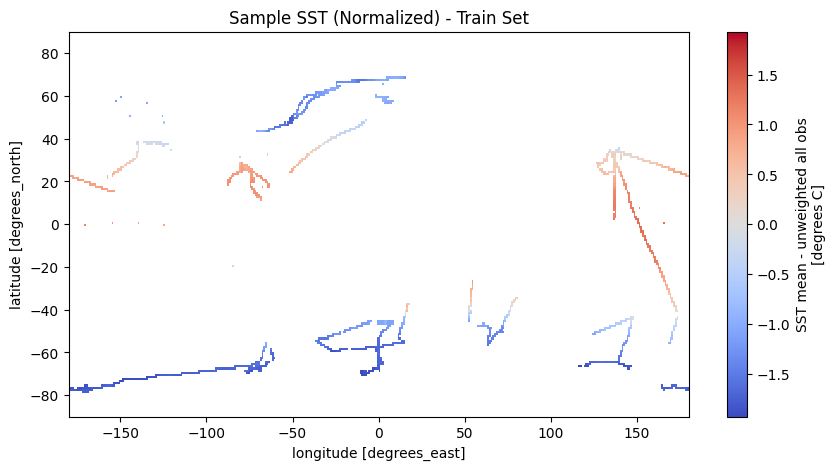

In [ ]:
# Load processed data
try:
    ds_train = xr.open_dataset(TRAIN_OUTPUT_PATH)
    ds_test = xr.open_dataset(TEST_OUTPUT_PATH)

    print("Train Shape:", ds_train.dims)
    print("Test Shape:", ds_test.dims)
    print("\nVariables:", list(ds_train.data_vars))
    
    # Quick Plot of first time step SST
    plt.figure(figsize=(10, 5))
    ds_train['sst'].isel(time=0).plot(cmap='coolwarm')
    plt.title("Sample SST (Normalized) - Train Set")
    plt.show()
    
except FileNotFoundError:
    print("❌ Processed files not found. Run the steps above.")